In [1]:
 import tensorrt
print(tensorrt.__version__)

10.10.0.31


In [2]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# Custom Dataset for PNG CT scan images
class CustomImageDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        # Only include files that are PNG images (or whatever extension you use)
        self.image_files = [
            f for f in sorted(os.listdir(image_dir))
            if os.path.isfile(os.path.join(image_dir, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        img = Image.open(img_path).convert("L")  # Grayscale
        if self.transform:
            img = self.transform(img)
        return img


# Transform: resize, tensor, normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

# Load dataset
dataset = CustomImageDataset("Images-CT", transform=transform)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)


In [3]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=128,
    in_channels=1,
    out_channels=1,
    layers_per_block=3,
    block_out_channels=(128,128,256,256,512,512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
)


2025-05-08 09:55:30.816771: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-08 09:55:31.427635: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [4]:
from diffusers import DDPMScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = DDPMScheduler(num_train_timesteps=2000)


In [5]:
num_epochs = 1000

for epoch in range(num_epochs):
    for batch in dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_images = scheduler.add_noise(batch, noise, timesteps)
        noise_pred = model(noisy_images, timesteps).sample
        loss = torch.nn.functional.mse_loss(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        torch.cuda.empty_cache()
    print(f"Epoch {epoch+1}/{num_epochs} completed. Loss: {loss.item()}")


Epoch 1/1000 completed. Loss: 0.027479639276862144
Epoch 2/1000 completed. Loss: 0.03613629564642906
Epoch 3/1000 completed. Loss: 0.08868830651044846
Epoch 4/1000 completed. Loss: 0.07648172229528427
Epoch 5/1000 completed. Loss: 0.021948549896478653
Epoch 6/1000 completed. Loss: 0.06674683094024658
Epoch 7/1000 completed. Loss: 0.046536874026060104
Epoch 8/1000 completed. Loss: 0.04635521024465561
Epoch 9/1000 completed. Loss: 0.009247089736163616
Epoch 10/1000 completed. Loss: 0.01681196317076683
Epoch 11/1000 completed. Loss: 0.009361235424876213
Epoch 12/1000 completed. Loss: 0.0460655614733696
Epoch 13/1000 completed. Loss: 0.03945152461528778
Epoch 14/1000 completed. Loss: 0.005592470522969961
Epoch 15/1000 completed. Loss: 0.01251304429024458
Epoch 16/1000 completed. Loss: 0.0020220656879246235
Epoch 17/1000 completed. Loss: 0.007066988851875067
Epoch 18/1000 completed. Loss: 0.03605387732386589
Epoch 19/1000 completed. Loss: 0.004456143826246262
Epoch 20/1000 completed. Loss: 

In [6]:
model.save_pretrained("Pre-built Diffusion (epoch=1000) CT-scan")


  0%|          | 0/25 [00:00<?, ?it/s]

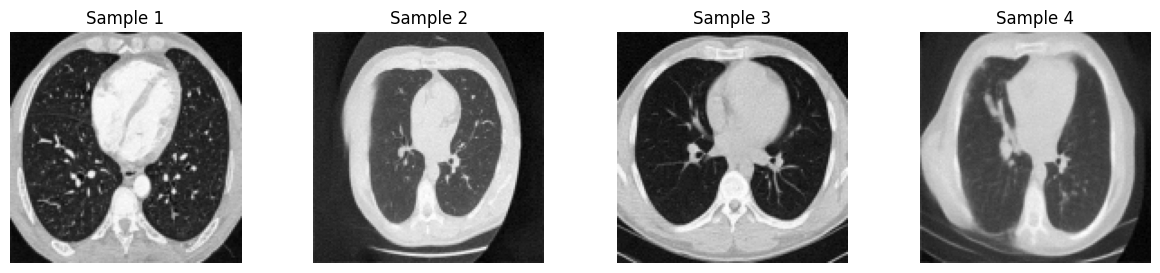

In [198]:
import torch
from diffusers import DDIMPipeline, DDIMScheduler, UNet2DModel
import matplotlib.pyplot as plt
from safetensors.torch import load_file

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Initialize the model architecture (same as training)
model = UNet2DModel(
    sample_size=128,
    in_channels=1,
    out_channels=1,
    layers_per_block=3,
    block_out_channels=(128,128,256,256,512,512),
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D", "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

# 2. Load the state dict from the safetensors file
state_dict = load_file("Pre-built Diffusion (epoch=1000) CT-scan/diffusion_pytorch_model.safetensors", device=device)
model.load_state_dict(state_dict)
model.eval()

# 3. Initialize DDIM scheduler and pipeline
scheduler = DDIMScheduler(num_train_timesteps=2000)
pipeline = DDIMPipeline(unet=model, scheduler=scheduler).to(device)

# 4. Generate samples
num_samples = 4
num_inference_steps = 25

with torch.no_grad():
    generated_images = pipeline(
        num_inference_steps=num_inference_steps,
        batch_size=num_samples
    ).images

# 5. Plot generated images
plt.figure(figsize=(15, 3))
for i, img in enumerate(generated_images):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"Sample {i+1}")
plt.show()


In [201]:
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim
import numpy as np

# 1. Convert generated images (PIL) to tensors in [0,1]
to_tensor = transforms.ToTensor()
gen_batch = torch.stack([to_tensor(img) for img in generated_images])  # [10, 1, 128, 128]

# 2. Denormalize real images from [-1,1] to [0,1]
def denorm(img):
    return ((img * 0.5) + 0.5).clamp(0, 1)
# Load one batch of real images from your dataloader
real_batch = next(iter(dataloader))  # shape: [batch_size, 1, 128, 128]
real_batch_01 = denorm(real_batch)

# 3. Compute SSIM
ssim_scores = []
for real, fake in zip(real_batch_01, gen_batch):
    real_np = real.squeeze().cpu().numpy()
    fake_np = fake.squeeze().cpu().numpy()
    score = ssim(real_np, fake_np, data_range=1.0)
    ssim_scores.append(score)

print(f"Mean SSIM: {np.mean(ssim_scores):.4f}")


Mean SSIM: 0.4056
